In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, LearningCurveDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.preprocessing import StandardScaler
import warnings

# Hides convergence warnings during cross-validation
warnings.filterwarnings("ignore")

In [2]:
print("Loading dataset...")
csv_path = "../dataset/raw/isl_landmarks.csv"

# Load the data
df = pd.read_csv(csv_path)

y = df["label"]
X_raw = df.drop("label", axis=1) 

# ========================================================
# APPLY DISTANCE TRANSFORMATION (126 -> 40 features)
# ========================================================
print("Converting raw coordinates to relative distances...")

def compute_distances(data):
    features = pd.DataFrame()
    for i in range(1, 21):
        features[f'L_dist_{i}'] = np.sqrt((data[f'L_x{i}'] - data['L_x0'])**2 + (data[f'L_y{i}'] - data['L_y0'])**2 + (data[f'L_z{i}'] - data['L_z0'])**2)
    for i in range(1, 21):
        features[f'R_dist_{i}'] = np.sqrt((data[f'R_x{i}'] - data['R_x0'])**2 + (data[f'R_y{i}'] - data['R_y0'])**2 + (data[f'R_z{i}'] - data['R_z0'])**2)
    return features.fillna(0)

X = compute_distances(X_raw)
print("Features shape after transformation:", X.shape) # Should print (..., 40)

Loading dataset...
Converting raw coordinates to relative distances...
Features shape after transformation: (26150, 40)


In [3]:
# Load your original encoder
encoder_path = "../models/label_encoder.pkl"

print(f"Loading encoder from: {encoder_path}")
encoder = joblib.load(encoder_path)
y_encoded = encoder.transform(y)

# Split data (using random_state=42 ensures the test set is exactly the same as training time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)
print("Data split complete!")

Loading encoder from: ../models/label_encoder.pkl
Data split complete!


In [4]:
# ==========================================
# CELL 4: PREPARE BOTH DATASETS
# ==========================================
print("Preparing BOTH 40-feature and 126-feature datasets...")

# 1. Split the raw 126 features exactly the same way as the 40 features
X_train_raw, X_test_raw, _, _ = train_test_split(
    X_raw, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 2. Scale the 40-feature dataset
scaler_40 = StandardScaler()
X_train_scaled_40 = scaler_40.fit_transform(X_train)
X_test_scaled_40 = scaler_40.transform(X_test)

# 3. Scale the 126-feature dataset
scaler_126 = StandardScaler()
X_train_scaled_126 = scaler_126.fit_transform(X_train_raw)
X_test_scaled_126 = scaler_126.transform(X_test_raw)

print("Data scaling complete! Both datasets are ready.")

Preparing BOTH 40-feature and 126-feature datasets...
Data scaling complete! Both datasets are ready.


In [5]:
print("Loading original 40-feature models into memory...")

models = {}

# Dictionary of all your saved model paths
model_files = {
    "KNN": "../models/knn_model.pkl",
    "SVM": "../models/svm_model.pkl",
    "MLP": "../models/mlp_model.pkl",
    "Random Forest": "../models/rf_model.pkl",
    "Ensemble": "../models/ensemble_model.pkl"
}

for name, filename in model_files.items():
    if os.path.exists(filename):
        models[name] = joblib.load(filename)
        print(f"  -> Successfully loaded: {name}")
    else:
        print(f"  -> WARNING: Could not find {filename}")
        
print(f"\nSuccessfully loaded {len(models)} models for comparison!")

Loading original 40-feature models into memory...
  -> Successfully loaded: KNN
  -> Successfully loaded: SVM
  -> Successfully loaded: MLP
  -> Successfully loaded: Random Forest
  -> Successfully loaded: Ensemble

Successfully loaded 5 models for comparison!


Starting Evaluation and Generating Accuracy Chart...



  File "e:\MANUMOTION\islenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\aatif\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\aatif\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\aatif\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


KNN             (126 features) Test Accuracy: 99.89%
SVM             (126 features) Test Accuracy: 99.98%
MLP             (126 features) Test Accuracy: 99.96%
Random Forest   (126 features) Test Accuracy: 99.90%
Ensemble        (40 features)  Test Accuracy: 99.90%


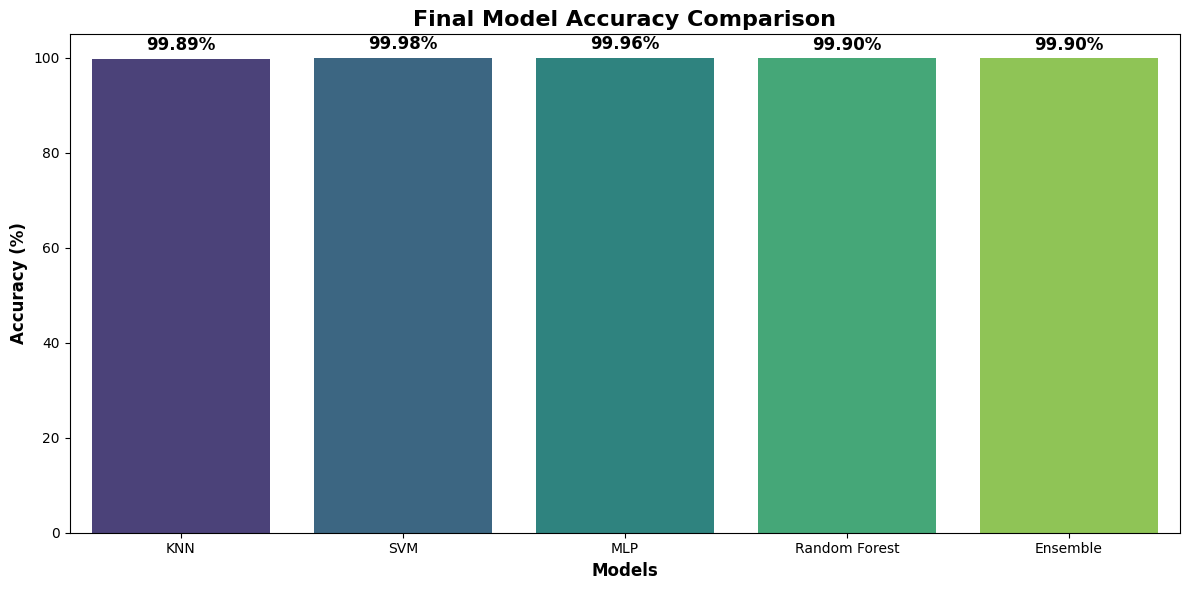

In [6]:
# ==========================================
# CELL 6: SMART ACCURACY EVALUATION
# ==========================================
print("Starting Evaluation and Generating Accuracy Chart...\n")
print("==================================================")

model_names = []
accuracies = []

for name, model in models.items():
    # DYNAMICALLY CHOOSE THE DATASET:
    # Check if the model was trained on 126 features or 40 features
    if getattr(model, "n_features_in_", 40) == 126:
        X_eval = X_test_scaled_126
        feature_text = "(126 features)"
    else:
        X_eval = X_test_scaled_40
        feature_text = "(40 features) "
        
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name:<15} {feature_text} Test Accuracy: {acc*100:.2f}%")
    
    model_names.append(name)
    accuracies.append(acc * 100)

# Create the bar chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=model_names, y=accuracies, palette="viridis")
plt.title("Final Model Accuracy Comparison", fontsize=16, fontweight='bold')
plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
plt.ylim(0, max(accuracies) + 5 if max(accuracies) + 5 <= 110 else 105) 

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, fontweight='bold', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

Generating Log Loss Chart (Lower is Better)...


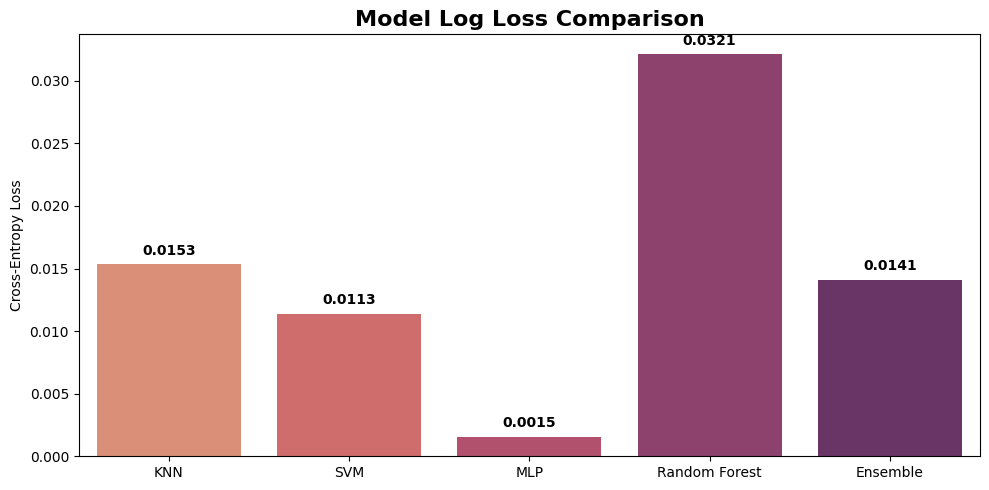

In [7]:
# ==========================================
# CELL 7: SMART LOG LOSS EVALUATION
# ==========================================
print("Generating Log Loss Chart (Lower is Better)...")
log_losses, model_names_loss = [], []

for name, model in models.items():
    try:
        # Choose the right dataset
        if getattr(model, "n_features_in_", 40) == 126:
            X_eval = X_test_scaled_126
        else:
            X_eval = X_test_scaled_40
            
        y_proba = model.predict_proba(X_eval)
        loss = log_loss(y_test, y_proba)
        log_losses.append(loss)
        model_names_loss.append(name)
    except Exception as e:
        print(f" -> Skipping {name} for log loss (Probability estimates not supported).")

if log_losses:
    plt.figure(figsize=(10, 5))
    ax2 = sns.barplot(x=model_names_loss, y=log_losses, palette="flare")
    plt.title("Model Log Loss Comparison", fontsize=16, fontweight='bold')
    plt.ylabel("Cross-Entropy Loss")
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', fontweight='bold', xytext=(0, 10), textcoords='offset points')
    plt.tight_layout()
    plt.show()

Generating Log Loss Chart (Lower is Better)...


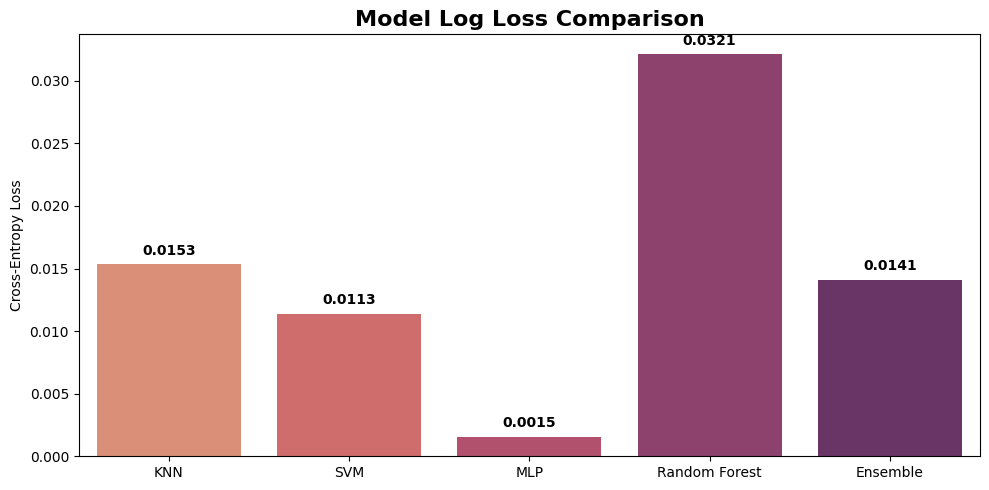

In [8]:
# ==========================================
# CELL 7: SMART LOG LOSS EVALUATION
# ==========================================
print("Generating Log Loss Chart (Lower is Better)...")
log_losses, model_names_loss = [], []

for name, model in models.items():
    try:
        # Choose the right dataset
        if getattr(model, "n_features_in_", 40) == 126:
            X_eval = X_test_scaled_126
        else:
            X_eval = X_test_scaled_40
            
        y_proba = model.predict_proba(X_eval)
        loss = log_loss(y_test, y_proba)
        log_losses.append(loss)
        model_names_loss.append(name)
    except Exception as e:
        print(f" -> Skipping {name} for log loss (Probability estimates not supported).")

if log_losses:
    plt.figure(figsize=(10, 5))
    ax2 = sns.barplot(x=model_names_loss, y=log_losses, palette="flare")
    plt.title("Model Log Loss Comparison", fontsize=16, fontweight='bold')
    plt.ylabel("Cross-Entropy Loss")
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', fontweight='bold', xytext=(0, 10), textcoords='offset points')
    plt.tight_layout()
    plt.show()

In [10]:
print("Loading dataset...")
csv_path = "../dataset/raw/isl_landmarks.csv"

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

y = df["label"]
X_raw = df.drop("label", axis=1)

# ========================================================
# 1. APPLY YOUR EXACT DISTANCE TRANSFORMATION (126 -> 40)
# ========================================================
print("Converting raw coordinates to relative distances...")

def compute_distances(data):
    features = pd.DataFrame()
    
    # Left Hand Distances
    for i in range(1, 21):
        features[f'L_dist_{i}'] = np.sqrt(
            (data[f'L_x{i}'] - data['L_x0'])**2 +
            (data[f'L_y{i}'] - data['L_y0'])**2 +
            (data[f'L_z{i}'] - data['L_z0'])**2
        )
        
    # Right Hand Distances
    for i in range(1, 21):
        features[f'R_dist_{i}'] = np.sqrt(
            (data[f'R_x{i}'] - data['R_x0'])**2 +
            (data[f'R_y{i}'] - data['R_y0'])**2 +
            (data[f'R_z{i}'] - data['R_z0'])**2
        )
    
    return features.fillna(0)

# Apply the transformation
X = compute_distances(X_raw)
print("Transformation complete. New shape:", X.shape)

# ========================================================
# 2. SPLIT AND SCALE THE 40 FEATURES
# ========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is ready for the models!")

Loading dataset...
Loading dataset from: ../dataset/raw/isl_landmarks.csv
Converting raw coordinates to relative distances...
Transformation complete. New shape: (26150, 40)
Data is ready for the models!
